In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA

%matplotlib inline

In [2]:
trainData = pd.read_csv("train.csv")
print(f"Training dataset shape: {trainData.shape}")

trainData.head()

missingDataVals = trainData.isnull().sum().sum()
print(f"Missing values in the data: {missingDataVals}")

xs = trainData.iloc[:, 1:] # pixel values normalized later
ys = trainData.iloc[:, 0] # just digit label

Training dataset shape: (42000, 785)
Missing values in the data: 0


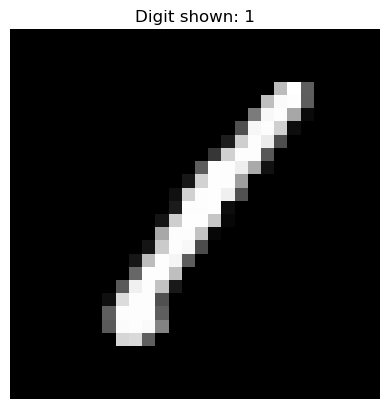

In [3]:
# Single Digit visualization:
firstImage = trainData.iloc[0, 1:].values
firstImage = firstImage.reshape(28, 28)

label = trainData.iloc[0, 0]

plt.imshow(firstImage, cmap = "gray")
plt.title(f"Digit shown: {label}")
plt.axis("off")
plt.show()

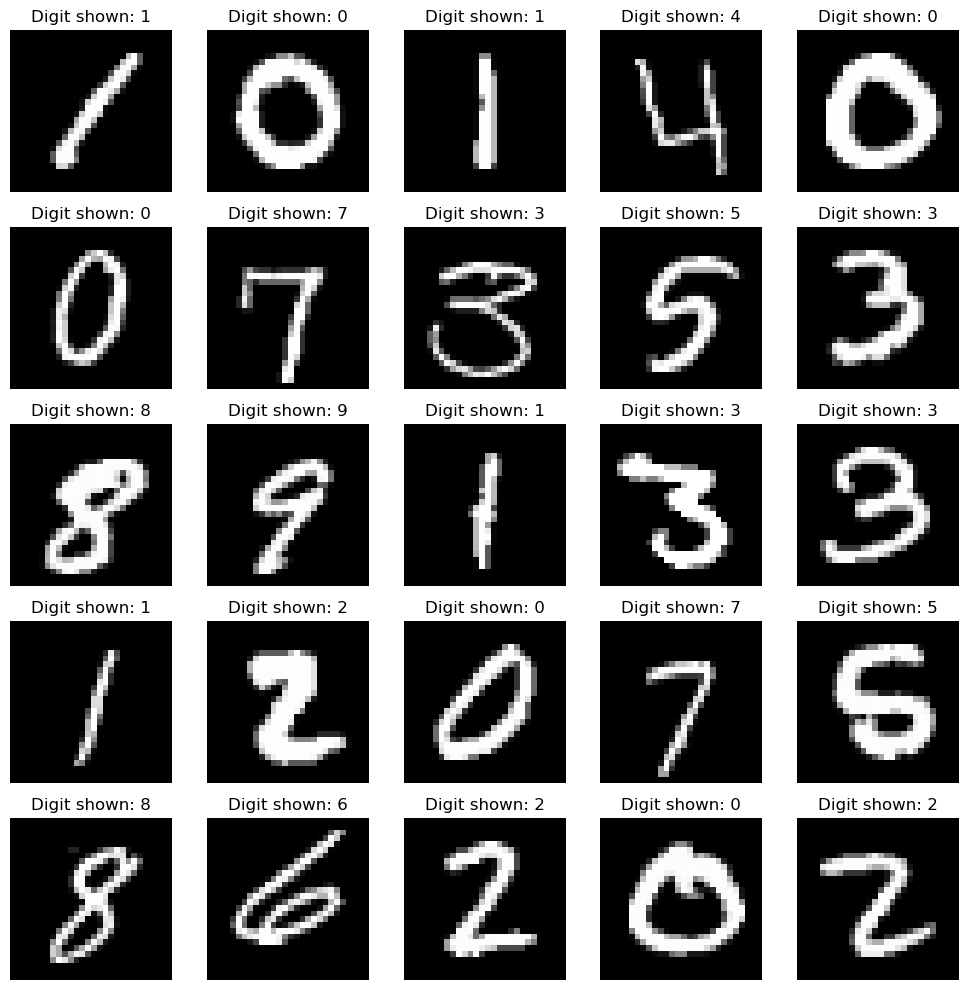

In [4]:
# Multiple Digit Visualization(Grid):
def plotGridDigitsDynamically(data, digitLabels, numImages = 25): # can adjust
    gridRows = int(np.ceil(np.sqrt(numImages)))
    gridCols = gridRows
    
    plt.figure(figsize = (gridCols * 2, gridRows * 2)) # can adjust
    for i in range(numImages):
        if i >= len(data):
            break
        image = data.iloc[i].values.reshape(28, 28)
        label = digitLabels.iloc[i]
        plt.subplot(gridRows, gridCols, i + 1)
        plt.imshow(image, cmap = "gray")
        plt.title(f"Digit shown: {label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plotGridDigitsDynamically(trainData.iloc[:25, 1:], trainData.iloc[:25, 0]) # can adjust 

In [5]:
# evaluate: training and validation split
# 0.8 train, 0.2 valid
trainX, validX, trainY, validY = train_test_split(xs, ys, test_size = 0.2, random_state = 42)
print(f"Train dataset shape(0.8): {trainX.shape}, {trainY.shape}")
print(f"Validation dataset shape(0.2): {validX.shape}, {validY.shape}")

Train dataset shape(0.8): (33600, 784), (33600,)
Validation dataset shape(0.2): (8400, 784), (8400,)


In [16]:
# Pipeline: Ensemble (VotingClassifier) Model: (Logistic Regression and Random Forest):
#  3+ Stages: Normalize, PCA, Classify (+ optimize hyperparameters):
ensemblePipeline = Pipeline([
    #stages
    ('normalize', FunctionTransformer(lambda x: x / 255.0)),
    ('pca', PCA()),
    ('classify', VotingClassifier(
        estimators = [ #  (Logistic Regression and Random Forest)
            ('logRegression', LogisticRegression(max_iter = 1000, random_state = 42)), ('rForest', RandomForestClassifier(random_state = 42))
        ],
        # combine predictions
        voting = 'soft'
    ))
])

# GridSearchCV: optimize hyperparams:
hyperParamGrid = {
    'pca__n_components': [50], 
    'classify__logRegression__C': [0.01, 0.1, 1], 
    'classify__rForest__n_estimators': [200], # num trees
    'classify__weights': [(1, 1), (2, 1)] # ensemble
}

# set up and fit to train dataset:
gridSearch_CV = GridSearchCV(ensemblePipeline, hyperParamGrid, cv = 3, scoring = 'accuracy', verbose = 2)
gridSearch_CV.fit(trainX, trainY)

print(f"(Ensemble)-GridSearchCV best params: {gridSearch_CV.best_params_}")
print(f"(Ensemble)-Best Cross-val accuracy: {gridSearch_CV.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END classify__logRegression__C=0.01, classify__rForest__n_estimators=200, classify__weights=(1, 1), pca__n_components=50; total time=  47.5s
[CV] END classify__logRegression__C=0.01, classify__rForest__n_estimators=200, classify__weights=(1, 1), pca__n_components=50; total time=  44.6s
[CV] END classify__logRegression__C=0.01, classify__rForest__n_estimators=200, classify__weights=(1, 1), pca__n_components=50; total time=  48.3s
[CV] END classify__logRegression__C=0.01, classify__rForest__n_estimators=200, classify__weights=(2, 1), pca__n_components=50; total time=  49.6s
[CV] END classify__logRegression__C=0.01, classify__rForest__n_estimators=200, classify__weights=(2, 1), pca__n_components=50; total time=  49.5s
[CV] END classify__logRegression__C=0.01, classify__rForest__n_estimators=200, classify__weights=(2, 1), pca__n_components=50; total time=  55.2s
[CV] END classify__logRegression__C=0.1, classify__rForest__n_es

In [18]:
# evaluate the best model with validation set:
bestModel = gridSearch_CV.best_estimator_
ensembleValidationPredictions = bestModel.predict(validX)
ensembleValidationAccuracy = accuracy_score(validY, ensembleValidationPredictions)

print(f"(Ensemble)-Validation dataset accuracy: {ensembleValidationAccuracy:.4f}")

(Ensemble)-Validation dataset accuracy: 0.9265


In [19]:
# retrain on entire dataset with tuned (Ensemble VotingClassifier) model:
fullTrainX = pd.concat([trainX, validX])
fullTrainY = pd.concat([trainY, validY])

bestModel.fit(fullTrainX, fullTrainY)
print("(Ensemble)-Model retrained on entire MNIST training dataset.")

(Ensemble)-Model retrained on entire MNIST training dataset.


In [21]:
# predict with test data and create submission file:

# predict with test dataset:
testData = pd.read_csv("test.csv") # from kaggle
testX = testData # already will be normalized
testLabelPredictions = bestModel.predict(testX)

# turn predictions into competition submission:
competitionSubmission = pd.DataFrame({
    'ImageId': np.arange(1, len(testLabelPredictions) + 1), 'Label': testLabelPredictions
})

competitionSubmission.to_csv("submission.csv", index = False)
print("created 'submission.csv' file.")

print(competitionSubmission.head()) # preview
print(f"Submission has total # rows: {len(competitionSubmission)}")

created 'submission.csv' file.
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      7
4        5      3
Submission has total # rows: 28000


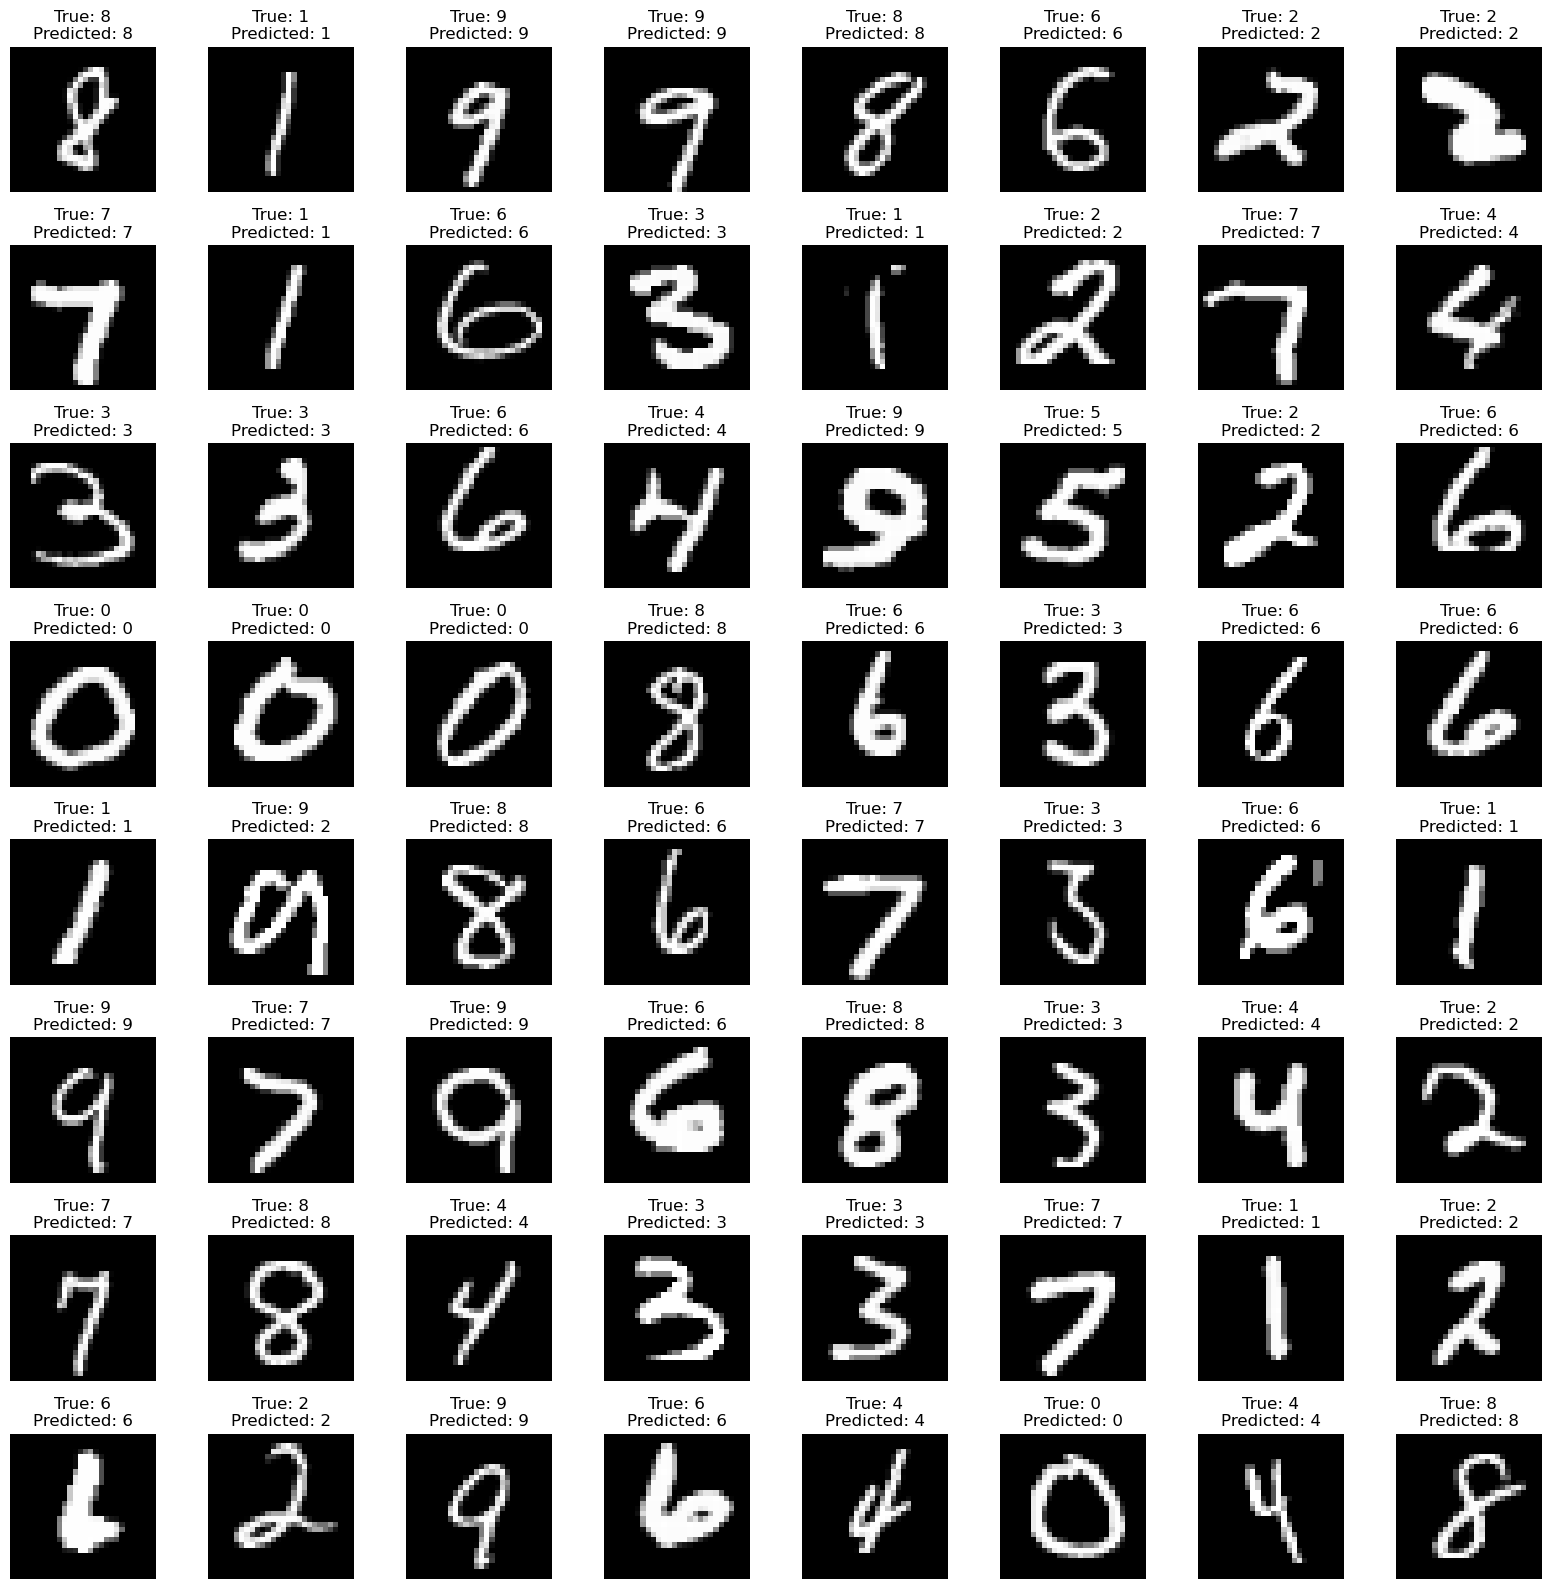

In [23]:
# performance visualization: (no true labels for test.csv, so validation will be used)
#  (validation dataset: 'test' data from test/train(0.2) split on train.csv)

# predict with validation data
validationPredictLabels = bestModel.predict(validX)

def plotGridPredictionDigits(digitImages, testLabels, predictLabels, numImagesDisplay = 9):
    gridRows = int(np.ceil(np.sqrt(numImagesDisplay)))
    gridCols = gridRows
    plt.figure(figsize=(gridCols * 2, gridRows * 2))

    for i in range(numImagesDisplay):
        digitImage = digitImages.iloc[i].values.reshape(28, 28)
        testLabel = testLabels.iloc[i]
        predictLabel = predictLabels[i]

        plt.subplot(gridRows, gridCols, i + 1)
        plt.imshow(digitImage, cmap = "gray")
        plt.title(f"True: {testLabel}\nPredicted: {predictLabel}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plotGridPredictionDigits(validX, validY, validationPredictLabels, numImagesDisplay = 64)
# plt.savefig('model_performance.png')